<a href="https://colab.research.google.com/github/stevefreund88-collab/hello-lab/blob/main/exercise_3_2_logistic_regression_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3.2: Logistic Regression Implementation

## Learning Objectives

By completing this exercise, you will:

- **Implement a complete classification workflow from data to predictions**
- **Understand and interpret probability predictions**
- **Preprocess text-based features for machine learning**
- **Evaluate classifier performance with multiple metrics**
- **Tune classification thresholds based on business needs**
- **Interpret model coefficients to understand feature importance**

---

## The Problem: Email Spam Classification

You're building an intelligent spam filter for a email service. Unlike Exercise 3.1 (which used just 2 features for visualization), you'll now work with a more realistic set of email features and implement the complete pipeline.

Business Goal: Classify emails as spam or legitimate while minimizing false positives (legitimate emails marked as spam).

---

## Setup: Import Required Libraries

In [24]:
# Data handling
import numpy as np
import pandas as pd

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part A: Load and Explore the Dataset

### Step 1: Create a Realistic Email Dataset

In [25]:
# Create a dataset with multiple email features
np.random.seed(42)

n_samples = 500

# Generate features for legitimate emails (250 samples)
legitimate_data = {
    'exclamation_marks': np.random.poisson(1, 250),  # Few exclamation marks
    'suspicious_words_count': np.random.poisson(2, 250),  # Few suspicious words
    'all_caps_words': np.random.poisson(1, 250),  # Few ALL CAPS words
    'has_unsubscribe': np.random.binomial(1, 0.8, 250),  # Usually has unsubscribe
    'subject_length': np.random.normal(40, 15, 250),  # Reasonable subject length
    'body_length': np.random.normal(500, 200, 250),  # Normal email length
    'contains_links': np.random.binomial(1, 0.3, 250),  # Some links
    'num_recipients': np.random.poisson(2, 250)  # Few recipients
}

# Generate features for spam emails (250 samples)
spam_data = {
    'exclamation_marks': np.random.poisson(5, 250),  # Many exclamation marks
    'suspicious_words_count': np.random.poisson(8, 250),  # Many suspicious words
    'all_caps_words': np.random.poisson(4, 250),  # Many ALL CAPS words
    'has_unsubscribe': np.random.binomial(1, 0.1, 250),  # Rarely has unsubscribe
    'subject_length': np.random.normal(60, 20, 250),  # Longer, sensational subjects
    'body_length': np.random.normal(300, 150, 250),  # Shorter, template-based
    'contains_links': np.random.binomial(1, 0.9, 250),  # Many links
    'num_recipients': np.random.poisson(50, 250)  # Mass email
}

# Combine into single DataFrame
df_legitimate = pd.DataFrame(legitimate_data)
df_legitimate['is_spam'] = 0

df_spam = pd.DataFrame(spam_data)
df_spam['is_spam'] = 1

df = pd.concat([df_legitimate, df_spam], ignore_index=True)

# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset created successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset created successfully!

Dataset shape: (500, 9)

First few rows:
   exclamation_marks  suspicious_words_count  all_caps_words  has_unsubscribe  \
0                  5                       7               4                0   
1                  0                       1               2                1   
2                  5                      14               5                0   
3                  2                       1               2                1   
4                  1                       2               1                1   

   subject_length  body_length  contains_links  num_recipients  is_spam  
0       36.938313   468.224882               1              45        1  
1       28.962123   413.968673               1               1        0  
2       45.773935   333.589031               1              48        1  
3       51.662969   798.383929               0               2        0  
4       28.962941   536.660042               0               4        0

### Step 2: Exploratory Data Analysis

In [26]:
# Basic statistics
print("\n" + "="*60)
print("DATASET STATISTICS")
print("="*60)
print(df.describe())

# Check class distribution
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)
print(df['is_spam'].value_counts())
print(f"\nSpam percentage: {df['is_spam'].mean()*100:.1f}%")

# Check for missing values
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())


DATASET STATISTICS
       exclamation_marks  suspicious_words_count  all_caps_words  \
count         500.000000               500.00000      500.000000   
mean            2.966000                 4.96200        2.404000   
std             2.659133                 3.61035        2.014174   
min             0.000000                 0.00000        0.000000   
25%             1.000000                 2.00000        1.000000   
50%             2.000000                 4.00000        2.000000   
75%             5.000000                 8.00000        4.000000   
max            11.000000                14.00000        8.000000   

       has_unsubscribe  subject_length  body_length  contains_links  \
count       500.000000      500.000000   500.000000      500.000000   
mean          0.444000       50.322123   400.159521        0.610000   
std           0.497352       20.632315   203.712742        0.488238   
min           0.000000       -4.420327  -156.698481        0.000000   
25%         

Question 1: Is our dataset balanced (roughly equal spam and legitimate emails)? Why does class balance matter in classification?

Your answer:

_Yes, there is a good balance between span and legitimate emails.  There are 59% of each. It is good to have a solid representation from each group. If not, it could lead to poor assumptions.

### Step 3: Visualize Feature Distributions

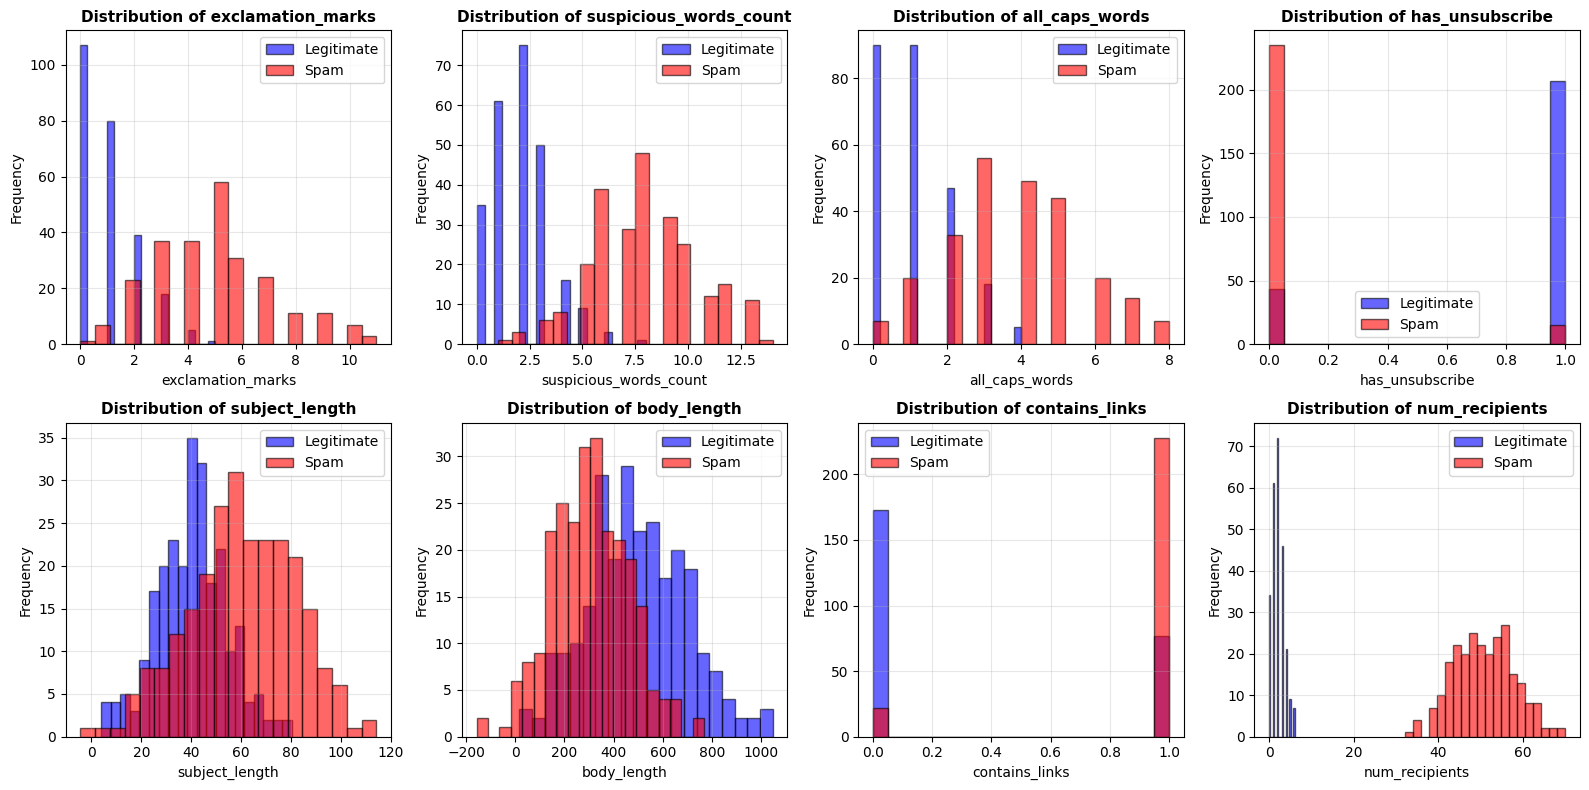

In [27]:
# Create subplots for key features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

features = ['exclamation_marks', 'suspicious_words_count', 'all_caps_words',
            'has_unsubscribe', 'subject_length', 'body_length',
            'contains_links', 'num_recipients']

for idx, feature in enumerate(features):
    ax = axes[idx]

    # Plot distributions for both classes
    df[df['is_spam']==0][feature].hist(ax=ax, bins=20, alpha=0.6,
                                         label='Legitimate', color='blue', edgecolor='black')
    df[df['is_spam']==1][feature].hist(ax=ax, bins=20, alpha=0.6,
                                         label='Spam', color='red', edgecolor='black')

    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Question 2: Which features show the clearest separation between spam and legitimate emails? Which features overlap the most?

Your answer:

_Distribution that has unsubscribe has the greatest seperation. The coorelation is negative. Emails with unsubscrbe were less likely to be span. The Discribution of containss_links has the greatest positive coorelation. Emails with links were more likley spam.  Distribution of body length has the most overlap.

---

## Part B: Data Preprocessing

### Step 1: Separate Features and Target

In [28]:
# Separate features (X) and target (y)
feature_columns = ['exclamation_marks', 'suspicious_words_count', 'all_caps_words',
                   'has_unsubscribe', 'subject_length', 'body_length',
                   'contains_links', 'num_recipients']

X = df[feature_columns]
y = df['is_spam']

print("Features (X):")
print(X.head())
print(f"\nShape: {X.shape}")

print("\n" + "="*60)
print("Target (y):")
print(y.head())
print(f"\nShape: {y.shape}")

Features (X):
   exclamation_marks  suspicious_words_count  all_caps_words  has_unsubscribe  \
0                  5                       7               4                0   
1                  0                       1               2                1   
2                  5                      14               5                0   
3                  2                       1               2                1   
4                  1                       2               1                1   

   subject_length  body_length  contains_links  num_recipients  
0       36.938313   468.224882               1              45  
1       28.962123   413.968673               1               1  
2       45.773935   333.589031               1              48  
3       51.662969   798.383929               0               2  
4       28.962941   536.660042               0               4  

Shape: (500, 8)

Target (y):
0    1
1    0
2    1
3    0
4    0
Name: is_spam, dtype: int64

Shape: (500,)


### Step 2: Split Data into Training and Testing Sets

In [29]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Split Complete!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Check class distribution in splits
print(f"\nTraining set spam rate: {y_train.mean()*100:.1f}%")
print(f"Testing set spam rate: {y_test.mean()*100:.1f}%")

Data Split Complete!
Training samples: 400
Testing samples: 100

Training set spam rate: 50.0%
Testing set spam rate: 50.0%


Question 3: What does stratify=y do? Why is it important for classification problems?

Your answer:

_it looks at the split between training and testing datasets.  It is critical that there is enough data to fill both of these pruppses.  If either is too small, it can lead to false assumptions.

### Step 3: Feature Scaling

In [30]:
# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easy viewing
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns)

print("Feature Scaling Complete!")
print("\nOriginal feature values (first 3 rows):")
print(X_train.head(3))

print("\nScaled feature values (first 3 rows):")
print(X_train_scaled.head(3))

Feature Scaling Complete!

Original feature values (first 3 rows):
     exclamation_marks  suspicious_words_count  all_caps_words  \
182                  2                      13               5   
471                  6                       7               3   
38                   2                       0               1   

     has_unsubscribe  subject_length  body_length  contains_links  \
182                0       30.789982   427.738657               1   
471                0       56.308971   359.306052               1   
38                 1       57.452632   626.672263               0   

     num_recipients  
182              55  
471              60  
38                1  

Scaled feature values (first 3 rows):
   exclamation_marks  suspicious_words_count  all_caps_words  has_unsubscribe  \
0          -0.358675                2.218828        1.274669        -0.904534   
1           1.112811                0.567607        0.282709        -0.904534   
2          -0.358675 

Question 4: Why do we scale features for logistic regression? What would happen if we didn't scale?

Your answer:

__Logistics regressingos uses Gradient Descent to find the best weights and establish the most optimal scale. It we didn't scale it would skew the data and cause issues with training (and extend training time).

---

## Part C: Build the Logistic Regression Model

### Step 1: Train the Model

In [31]:
# Create and train logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Fit the model
log_reg.fit(X_train_scaled, y_train)

print("✓ Model trained successfully!")
print(f"\nModel parameters:")
print(f"Number of iterations to converge: {log_reg.n_iter_[0]}")

✓ Model trained successfully!

Model parameters:
Number of iterations to converge: 10


### Step 2: Examine Model Coefficients


MODEL COEFFICIENTS (Sorted by Importance)
               Feature  Coefficient  Abs_Coefficient
        num_recipients     2.362603         2.362603
suspicious_words_count     1.266507         1.266507
     exclamation_marks     1.138728         1.138728
        all_caps_words     0.815515         0.815515
       has_unsubscribe    -0.666996         0.666996
        contains_links     0.649571         0.649571
        subject_length     0.646852         0.646852
           body_length    -0.452951         0.452951


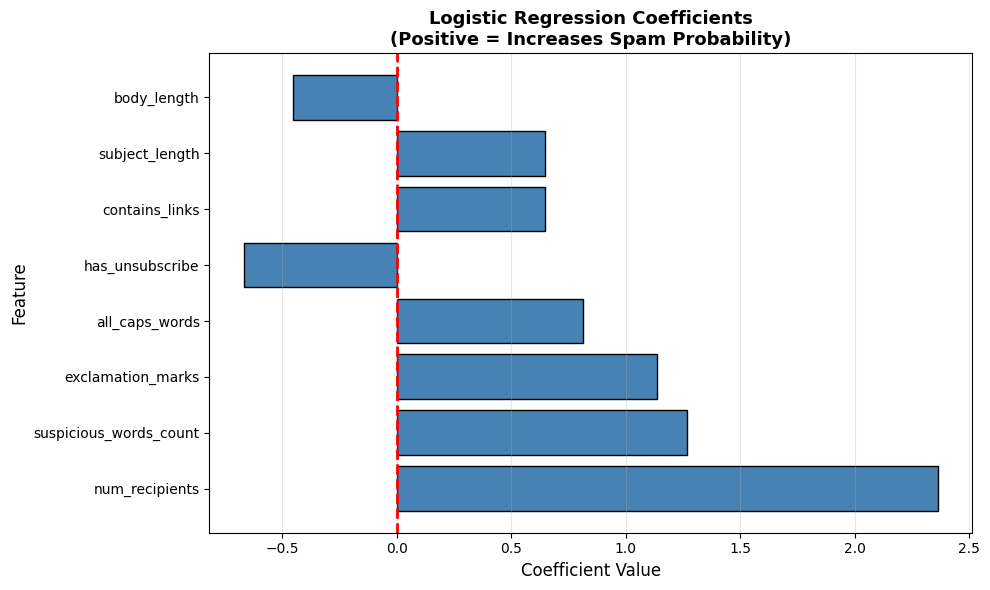

In [32]:
# Get coefficients
coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': log_reg.coef_[0],
    'Abs_Coefficient': np.abs(log_reg.coef_[0])
})

# Sort by absolute value
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("\n" + "="*60)
print("MODEL COEFFICIENTS (Sorted by Importance)")
print("="*60)
print(coefficients.to_string(index=False))

# Visualize coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='steelblue', edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Logistic Regression Coefficients\n(Positive = Increases Spam Probability)',
          fontsize=13, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Question 5: Which feature has the strongest positive coefficient (most spam-indicating)? Which has the strongest negative coefficient (most legitimate-indicating)? Interpret what these mean.

Your answer:

___The number of recipients has the greatest positive coefficient and the has_unsubscribe has the greatest negative coefficient. Emails that allow you to unsubscribe are more trusted and those which a mass distributed are less.

---

## Part D: Make Predictions (Understanding Probabilities)

### Step 1: Binary Predictions (Default Threshold = 0.5)

In [33]:
# Make binary predictions on test set
y_pred = log_reg.predict(X_test_scaled)

print("Sample Predictions (First 10):")
print(f"Actual:    {list(y_test[:10].values)}")
print(f"Predicted: {list(y_pred[:10])}")

Sample Predictions (First 10):
Actual:    [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]
Predicted: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]


### Step 2: Probability Predictions

Here's where logistic regression shines - it gives us probabilities, not just yes/no answers!

In [34]:
# Get probability predictions
y_pred_proba = log_reg.predict_proba(X_test_scaled)

# Make binary predictions on test set (moved from previous cell to ensure definition)
y_pred = log_reg.predict(X_test_scaled)

# Create comparison DataFrame
prediction_df = pd.DataFrame({
    'Actual_Label': y_test.values,
    'Prob_Legitimate': y_pred_proba[:, 0],  # Probability of class 0 (legitimate)
    'Prob_Spam': y_pred_proba[:, 1],        # Probability of class 1 (spam)
    'Predicted_Label': y_pred,
    'Correct': y_test.values == y_pred
})

print("\n" + "="*60)
print("SAMPLE PREDICTIONS WITH PROBABILITIES")
print("="*60)
print(prediction_df.head(15))

# Show some interesting cases
print("\n" + "="*60)
print("HIGH CONFIDENCE SPAM (Prob > 0.9)")
print("="*60)
high_conf_spam = prediction_df[prediction_df['Prob_Spam'] > 0.9].head()
print(high_conf_spam)

print("\n" + "="*60)
print("UNCERTAIN PREDICTIONS (0.4 < Prob < 0.6)")
print("="*60)
uncertain = prediction_df[(prediction_df['Prob_Spam'] > 0.4) &
                         (prediction_df['Prob_Spam'] < 0.6)].head()
print(uncertain)


SAMPLE PREDICTIONS WITH PROBABILITIES
    Actual_Label  Prob_Legitimate  Prob_Spam  Predicted_Label  Correct
0              1         0.000764   0.999236                1     True
1              0         0.993014   0.006986                0     True
2              0         0.996132   0.003868                0     True
3              1         0.000516   0.999484                1     True
4              1         0.007363   0.992637                1     True
5              1         0.007686   0.992314                1     True
6              1         0.006033   0.993967                1     True
7              0         0.999372   0.000628                0     True
8              0         0.988859   0.011141                0     True
9              0         0.996829   0.003171                0     True
10             0         0.992462   0.007538                0     True
11             0         0.990533   0.009467                0     True
12             1         0.002982   0.

Question 6: Why are probability predictions more useful than binary predictions? Give a real-world example where knowing the probability matters.

Your answer:

Binary predictions require yes/no or 0 or 1 answers. Probably can be scored in levels of confidence.  A good example is cancer diagnosis.  It would be good to understand the probably that one would have cancer when considering treatments rather than typical yes/no.

### Step 3: Visualize Probability Distribution

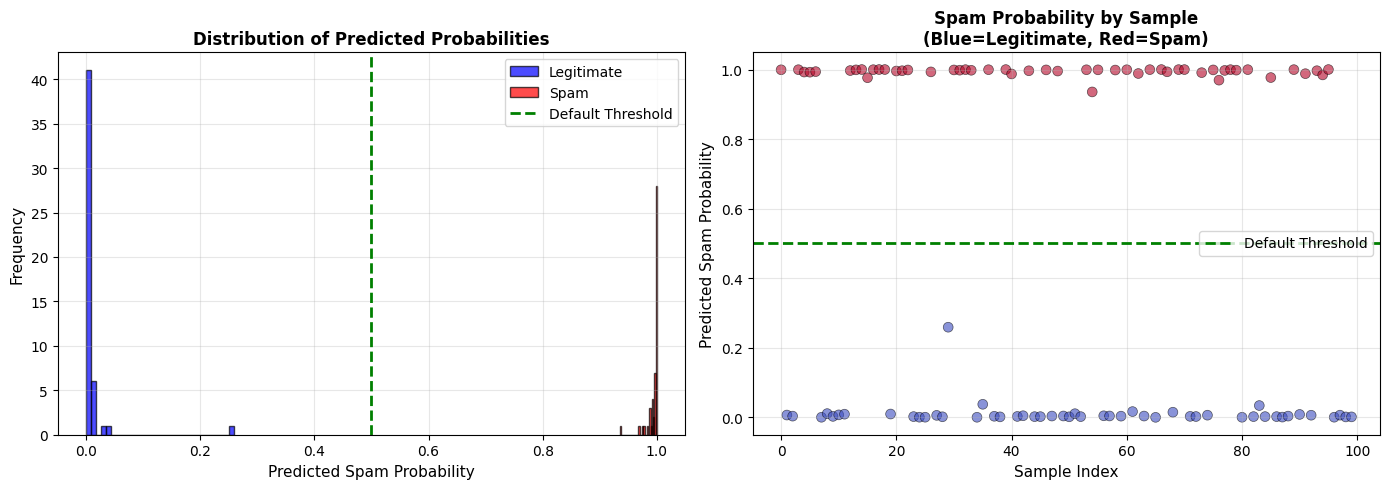

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Histogram of spam probabilities
axes[0].hist(prediction_df[prediction_df['Actual_Label']==0]['Prob_Spam'],
            bins=30, alpha=0.7, label='Legitimate', color='blue', edgecolor='black')
axes[0].hist(prediction_df[prediction_df['Actual_Label']==1]['Prob_Spam'],
            bins=30, alpha=0.7, label='Spam', color='red', edgecolor='black')
axes[0].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Default Threshold')
axes[0].set_xlabel('Predicted Spam Probability', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Scatter plot of probabilities
axes[1].scatter(range(len(prediction_df)), prediction_df['Prob_Spam'],
               c=prediction_df['Actual_Label'], cmap='coolwarm',
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0.5, color='green', linestyle='--', linewidth=2, label='Default Threshold')
axes[1].set_xlabel('Sample Index', fontsize=11)
axes[1].set_ylabel('Predicted Spam Probability', fontsize=11)
axes[1].set_title('Spam Probability by Sample\n(Blue=Legitimate, Red=Spam)',
                 fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Question 7: Looking at the left histogram, are there many samples near the 0.5 threshold (uncertain predictions)? What does this tell us about the model's confidence?

Your answer:

_______________________________________________

---

## Part E: Evaluate Model Performance

### Step 1: Confusion Matrix

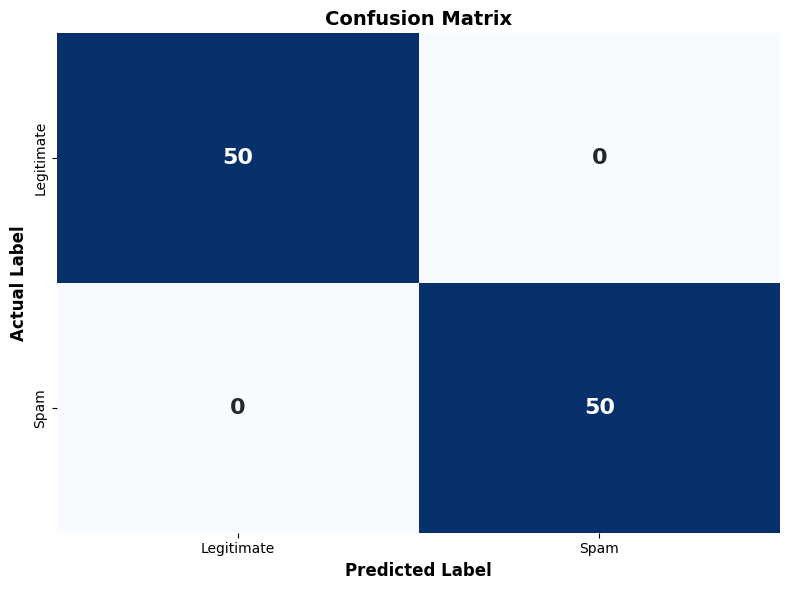


CONFUSION MATRIX BREAKDOWN
True Negatives (TN): 50  → Correctly identified legitimate emails
False Positives (FP): 0 → Legitimate emails marked as spam (BAD!)
False Negatives (FN): 0 → Spam emails marked as legitimate
True Positives (TP): 50  → Correctly identified spam emails


In [36]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
           xticklabels=['Legitimate', 'Spam'],
           yticklabels=['Legitimate', 'Spam'],
           annot_kws={'size': 16, 'weight': 'bold'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print("\n" + "="*60)
print("CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"True Negatives (TN): {tn}  → Correctly identified legitimate emails")
print(f"False Positives (FP): {fp} → Legitimate emails marked as spam (BAD!)")
print(f"False Negatives (FN): {fn} → Spam emails marked as legitimate")
print(f"True Positives (TP): {tp}  → Correctly identified spam emails")

Question 8: In the context of email filtering, which is worse: false positives or false negatives? Why?

Your answer: A false postive is worse. If an important email is sent to spam, it could allow the user to miss something. With a human in the loop, they can detect spam and ignore it if the filter misses it.
_______________________________________________

### Step 2: Calculate Performance Metrics

In [37]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

print("\n" + "="*60)
print("METRIC INTERPRETATIONS")
print("="*60)
print(f"Accuracy:  {accuracy*100:.1f}% of all predictions are correct")
print(f"Precision: {precision*100:.1f}% of spam predictions are actually spam")
print(f"Recall:    {recall*100:.1f}% of actual spam emails are caught")
print(f"F1-Score:  Harmonic mean of precision and recall")

# Detailed classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Spam']))


PERFORMANCE METRICS
Accuracy:  1.0000 (100.00%)
Precision: 1.0000 (100.00%)
Recall:    1.0000 (100.00%)
F1-Score:  1.0000

METRIC INTERPRETATIONS
Accuracy:  100.0% of all predictions are correct
Precision: 100.0% of spam predictions are actually spam
Recall:    100.0% of actual spam emails are caught
F1-Score:  Harmonic mean of precision and recall

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00        50
        Spam       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



Question 9: If you had to choose between maximizing precision or recall for spam detection, which would you choose and why? (Hint: Consider the consequences of each type of error)

Your answer:

I would rather maximize percision to ensure that important emails are not flagged and missed. This ensure more stable communication.  

---

## Part F: Threshold Tuning

The default threshold is 0.5, but we can adjust it based on business needs!

### Step 1: Explore Different Thresholds

In [38]:
# Test different thresholds
thresholds = [0.3, 0.5, 0.7, 0.9]
threshold_results = []

for threshold in thresholds:
    # Make predictions with custom threshold
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    f1_custom = f1_score(y_test, y_pred_custom)

    # Count false positives
    cm_custom = confusion_matrix(y_test, y_pred_custom)
    fp = cm_custom[0, 1]

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1_custom,
        'False_Positives': fp
    })

# Display results
results_df = pd.DataFrame(threshold_results)
print("\n" + "="*60)
print("THRESHOLD COMPARISON")
print("="*60)
print(results_df.to_string(index=False))


THRESHOLD COMPARISON
 Threshold  Accuracy  Precision  Recall  F1-Score  False_Positives
       0.3       1.0        1.0     1.0       1.0                0
       0.5       1.0        1.0     1.0       1.0                0
       0.7       1.0        1.0     1.0       1.0                0
       0.9       1.0        1.0     1.0       1.0                0


Question 10: How does increasing the threshold from 0.3 to 0.9 affect precision and recall? Explain the trade-off.

Your answer:

__For this dataset, there is no difference in increasing the threshold from .3 to .9. There is no real impact.

### Step 2: Visualize Threshold Impact

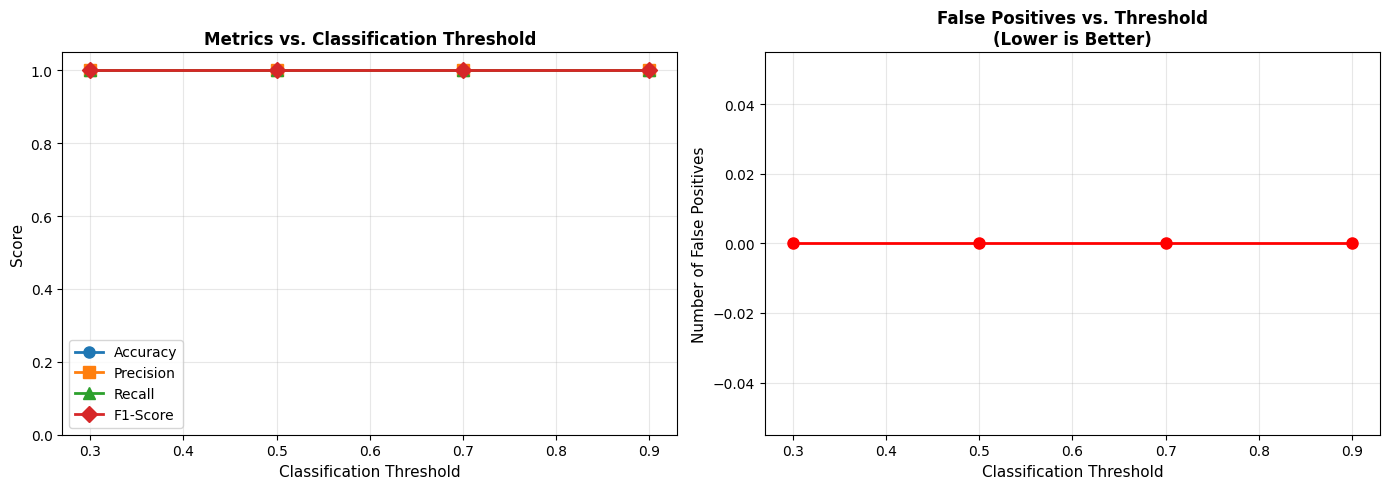

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Metrics vs Threshold
axes[0].plot(results_df['Threshold'], results_df['Accuracy'],
            marker='o', linewidth=2, markersize=8, label='Accuracy')
axes[0].plot(results_df['Threshold'], results_df['Precision'],
            marker='s', linewidth=2, markersize=8, label='Precision')
axes[0].plot(results_df['Threshold'], results_df['Recall'],
            marker='^', linewidth=2, markersize=8, label='Recall')
axes[0].plot(results_df['Threshold'], results_df['F1-Score'],
            marker='D', linewidth=2, markersize=8, label='F1-Score')
axes[0].set_xlabel('Classification Threshold', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Metrics vs. Classification Threshold', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Right plot: False Positives vs Threshold
axes[1].plot(results_df['Threshold'], results_df['False_Positives'],
            marker='o', linewidth=2, markersize=8, color='red')
axes[1].set_xlabel('Classification Threshold', fontsize=11)
axes[1].set_ylabel('Number of False Positives', fontsize=11)
axes[1].set_title('False Positives vs. Threshold\n(Lower is Better)',
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Question 11: Based on the plots, which threshold would you recommend if minimizing false positives is the top priority? Justify your choice.

Your answer:

__There are no error differences based on threshold. I would therefore suggest a high threshold to provide additional safety without the tradeoff.

---

## Part G: ROC Curve and AUC

The ROC curve shows classifier performance across all possible thresholds:

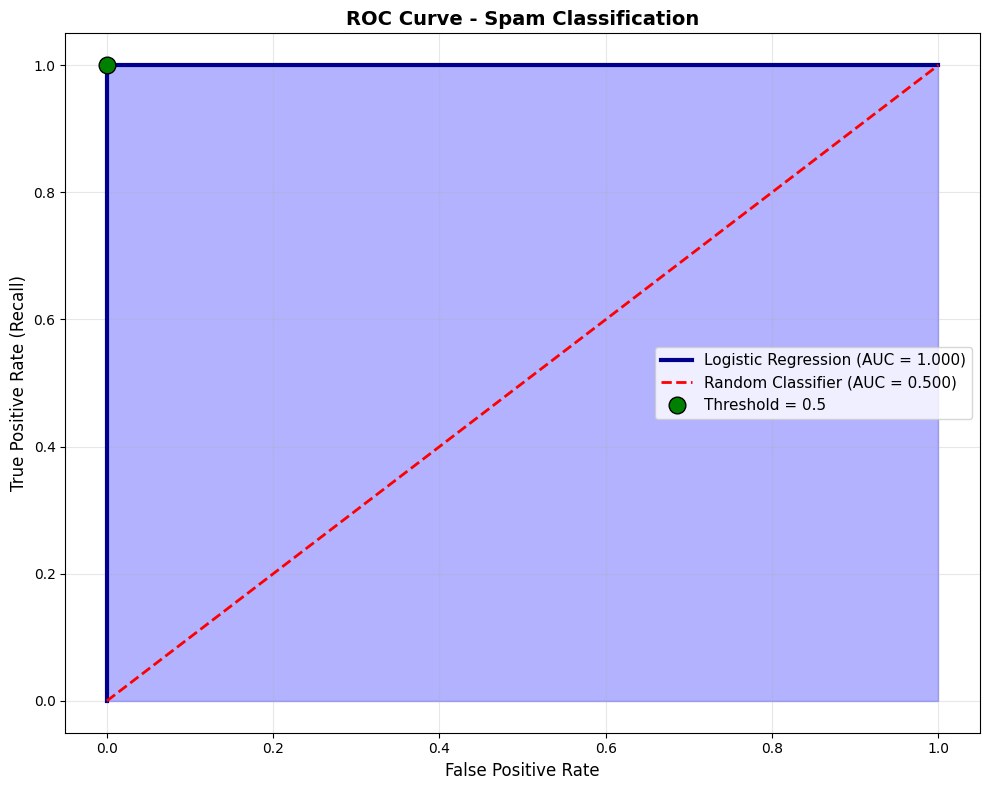


Area Under Curve (AUC): 1.0000

AUC Interpretation:
• 0.5 = Random guessing
• 0.7-0.8 = Acceptable
• 0.8-0.9 = Excellent
• 0.9-1.0 = Outstanding

Our model: Outstanding


In [40]:
# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=3, label=f'Logistic Regression (AUC = {auc_score:.3f})', color='darkblue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')

# Mark the default threshold point (0.5)
default_threshold_idx = np.argmin(np.abs(roc_thresholds - 0.5))
plt.plot(fpr[default_threshold_idx], tpr[default_threshold_idx],
        'go', markersize=12, label=f'Threshold = 0.5', markeredgecolor='black', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Spam Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nArea Under Curve (AUC): {auc_score:.4f}")
print("\nAUC Interpretation:")
print(f"• 0.5 = Random guessing")
print(f"• 0.7-0.8 = Acceptable")
print(f"• 0.8-0.9 = Excellent")
print(f"• 0.9-1.0 = Outstanding")
print(f"\nOur model: {'Outstanding' if auc_score >= 0.9 else 'Excellent' if auc_score >= 0.8 else 'Acceptable'}")

Question 12: What does the AUC score represent? Why is it useful compared to just looking at accuracy?

Your answer: Area under curve represents the probability that the system will corectly cooreldate. It is an additional threshold number that can further support if the data is accurate or not. It can more effectively handle imbalanced data.

_______________________________________________

---

## Part H: Make Predictions on New Emails

Let's use our trained model on new, unseen emails:

In [41]:
# Create new email samples
new_emails = pd.DataFrame({
    'exclamation_marks': [0, 8, 2, 15],
    'suspicious_words_count': [1, 12, 3, 20],
    'all_caps_words': [0, 6, 1, 10],
    'has_unsubscribe': [1, 0, 1, 0],
    'subject_length': [35, 75, 42, 90],
    'body_length': [600, 200, 550, 150],
    'contains_links': [0, 1, 1, 1],
    'num_recipients': [1, 100, 3, 200]
})

# Scale the features
new_emails_scaled = scaler.transform(new_emails)

# Predict probabilities
new_predictions = log_reg.predict_proba(new_emails_scaled)
new_labels = log_reg.predict(new_emails_scaled)

# Display results
results = pd.DataFrame({
    'Email_ID': [1, 2, 3, 4],
    'Prob_Legitimate': new_predictions[:, 0],
    'Prob_Spam': new_predictions[:, 1],
    'Prediction': ['Legitimate' if label == 0 else 'Spam' for label in new_labels],
    'Confidence': np.max(new_predictions, axis=1)
})

print("\n" + "="*60)
print("PREDICTIONS FOR NEW EMAILS")
print("="*60)
print(results.to_string(index=False))

# Show feature values
print("\n" + "="*60)
print("EMAIL FEATURES")
print("="*60)
print(new_emails)


PREDICTIONS FOR NEW EMAILS
 Email_ID  Prob_Legitimate  Prob_Spam Prediction  Confidence
        1     9.996868e-01   0.000313 Legitimate    0.999687
        2     1.423956e-07   1.000000       Spam    1.000000
        3     9.863450e-01   0.013655 Legitimate    0.986345
        4     3.774758e-15   1.000000       Spam    1.000000

EMAIL FEATURES
   exclamation_marks  suspicious_words_count  all_caps_words  has_unsubscribe  \
0                  0                       1               0                1   
1                  8                      12               6                0   
2                  2                       3               1                1   
3                 15                      20              10                0   

   subject_length  body_length  contains_links  num_recipients  
0              35          600               0               1  
1              75          200               1             100  
2              42          550               1    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Question 13: Based on the features and predictions, which email would you be most confident about classifying? Which would need human review?

Your answer:

__Email 2 and Email 4 would have the most confidence.  Both are 100%.  Email 3 has the lowest score and should have a human in the loop for review.

---

## Part I: Feature Importance Deep Dive

Let's understand which features matter most:

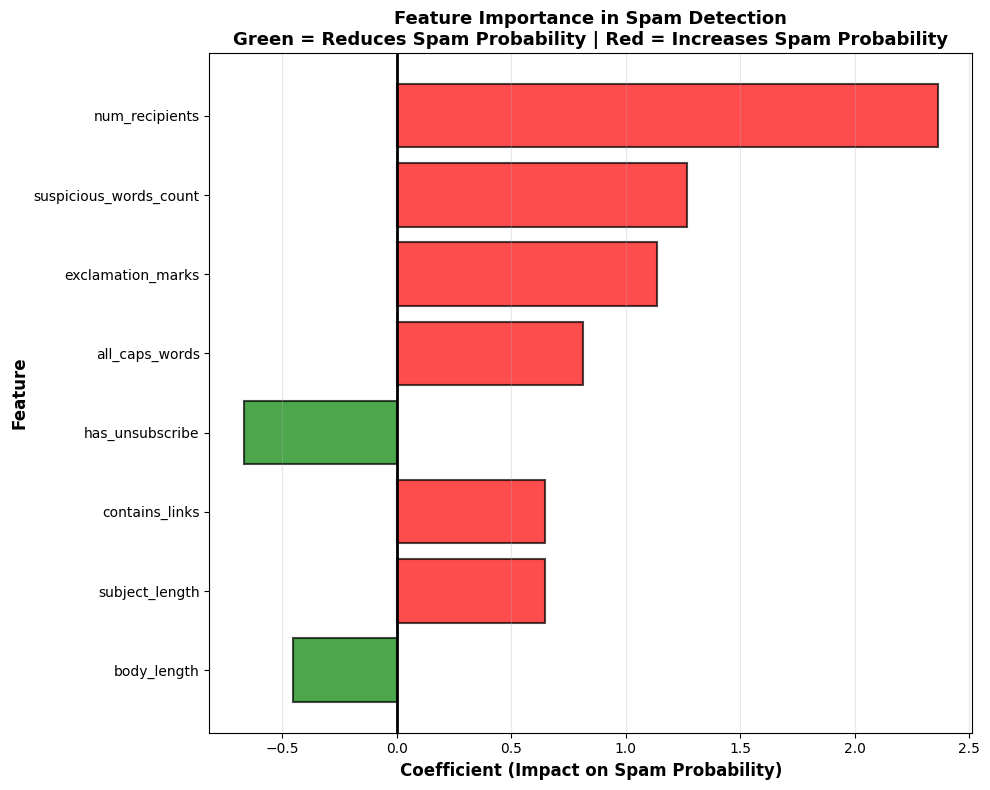


FEATURE IMPORTANCE RANKING
               Feature  Coefficient  Abs_Coefficient         Impact
        num_recipients     2.362603         2.362603 Increases Spam
suspicious_words_count     1.266507         1.266507 Increases Spam
     exclamation_marks     1.138728         1.138728 Increases Spam
        all_caps_words     0.815515         0.815515 Increases Spam
       has_unsubscribe    -0.666996         0.666996 Decreases Spam
        contains_links     0.649571         0.649571 Increases Spam
        subject_length     0.646852         0.646852 Increases Spam
           body_length    -0.452951         0.452951 Decreases Spam


In [42]:
# Get feature importance from coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': log_reg.coef_[0],
    'Abs_Coefficient': np.abs(log_reg.coef_[0]),
    'Impact': ['Increases Spam' if c > 0 else 'Decreases Spam'
               for c in log_reg.coef_[0]]
})

feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=True)

# Create horizontal bar plot
plt.figure(figsize=(10, 8))
colors = ['green' if c < 0 else 'red' for c in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'],
        color=colors, edgecolor='black', linewidth=1.5, alpha=0.7)
plt.xlabel('Coefficient (Impact on Spam Probability)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Feature Importance in Spam Detection\nGreen = Reduces Spam Probability | Red = Increases Spam Probability',
         fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FEATURE IMPORTANCE RANKING")
print("="*60)
print(feature_importance.sort_values('Abs_Coefficient', ascending=False).to_string(index=False))

---

## Part J: Complete Pipeline Code

Here's everything in one place:

In [43]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Load data (your data loading code here)
# ...

# Preprocess
X = df[feature_columns]
y = df['is_spam']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%


---

## Part K: Reflection and Extensions

### Reflection Questions

1. **Probability Interpretation: How does logistic regression compute probabilities? Why can't linear regression be used for classification?**  Logistic regression calculates probabilities using a standard linear cobination of features such as Logistical functions. Linear progression predicts 0 and 1 whihle logistical can assess probabiltities and deals with outliefers
2. **Feature Engineering: What other email features could improve spam detection? (Think about sender reputation, time of day, etc.)** It would be good to have the system load or learn that some senders are more trustworthy than others. It would be good to provide these trusted senders with additional freedom.
3. **Threshold Selection: In practice, who should decide the classification threshold - data scientists or business stakeholders? Why?** It should be a collaboration between data scientiests and stakeholders. The scientiests can explain tradeoffs and the stakeholder would make the final decision.
4. **Ethical Considerations: What are the ethical implications of aggressive spam filtering? How might false positives harm users?** Designers of filter systems must fully understand the cultural practices of their audiences. They don't want to establish pactices that punish a community due to cultural practices.
5. **Model Limitations: Under what circumstances might this spam filter fail? Can you think of ways spammers could "game" the system?**  the system could fail due to false positives or nagatives. Senders who were aware of the system paramters would be able to game the system by avoiding the traps.

### Extension Challenges

Challenge 1 - Text Features: Research how to extract features from actual email text using TF-IDF or word counts. Implement a spam classifier on real text data.

Challenge 2 - Cross-Validation: Implement k-fold cross-validation to get more robust performance estimates.

Challenge 3 - Feature Selection: Try removing the least important features. Does model performance improve or degrade?

Challenge 4 - Regularization: Research L1 and L2 regularization. Implement logistic regression with different regularization strengths and compare results.

Challenge 5 - Comparison: Train a Random Forest or SVM on the same data. Which performs better? Why?

Challenge 6 - Real Dataset: Find a real spam dataset (like the UCI Spambase dataset) and apply this entire workflow.

---

## Key Takeaways

✓ Complete workflow: Data loading → Preprocessing → Training → Evaluation → Deployment

✓ Probabilities: Logistic regression provides probability scores, not just binary predictions

✓ Thresholds: The 0.5 default isn't always optimal - tune based on business needs

✓ Metrics matter: Accuracy alone is insufficient - consider precision, recall, F1

✓ Feature scaling: Essential for logistic regression to converge and work properly

✓ Coefficients: Directly interpretable - show feature importance and direction

✓ ROC/AUC: Evaluates performance across all thresholds simultaneously

✓ Trade-offs: Higher thresholds reduce false positives but increase false negatives